# Disaster Tweets: A Complete Machine Learning Project Tutorial

I built this notebook to predict whether a tweet describes a **real
disaster** (`"Disaster"`) or **not** (`"Not Disaster"`), from its raw
text, `keyword`, and `location` fields — the classic "Real or Not? NLP
with Disaster Tweets" task. I wanted a text-classification project
after working mostly with tabular data before, to see how much of what
I'd learned about imbalanced classes and model comparison would carry
over when the features are words instead of numbers.

## What I worked through here

1. **Data-quality investigation as a first-class step**: exact-duplicate
   tweets, some with *conflicting* labels; a `keyword` column with raw
   URL-encoding artifacts; a `location` column too sparse and
   inconsistent to use as a categorical feature
2. **TF-IDF feature engineering for text**, plus hand-crafted numeric
   signals (length, URL/mention/hashtag counts) — a genuinely different
   feature-engineering approach than I'd used on tabular data before
3. **Moderate class imbalance**, measured rather than assumed, and why
   I used macro-F1 throughout instead of accuracy
4. **Class-imbalance handling, compared honestly**: class-weighting vs.
   `RandomOverSampler` (not ADASYN — see why below) vs. doing nothing
5. **A model choice driven by more than macro-F1 alone**: the
   best-scoring model on cross-validation turned out to be impractical
   to explain with SHAP, which changed my final production choice
6. **Decision-threshold tuning** as a precision/recall tradeoff
7. **SHAP** for a tree-based text classifier
8. A **written discussion** of this project's limits and what a real
   disaster-response triage system would need beyond it

**Before running:** download the dataset — see the project README's
"Get the data" section — so that `data/raw/tweets.csv` exists.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from disaster_tweets_nlp import config, data, features, model, interpretability

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Load the data

In [2]:
df = data.load_tweets()
print(f"{len(df)} rows, {df.shape[1]} columns")
df.head()

11370 rows, 5 columns


,id,keyword,location,text,target
0,0,ablaze,NaN,"Communal violence in Bhainsa, Telangana. ""Ston...",1
1,1,ablaze,NaN,Telangana: Section 144 has been imposed in Bha...,1
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https:...,1
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https:...,1
4,4,ablaze,NaN,"""Lord Jesus, your love brings freedom and pard...",0


## 2. Explore the data (EDA)

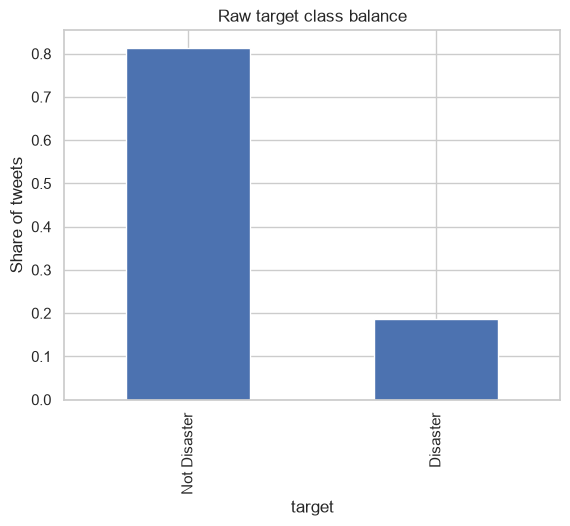

In [3]:
df[config.TARGET_COL].value_counts(normalize=True).rename({0: "Not Disaster", 1: "Disaster"}).plot.bar(
    title="Raw target class balance"
)
plt.ylabel("Share of tweets")
plt.show()

### Concept: this imbalance is moderate, not extreme

"Disaster" is ~18.4% of rows. That's imbalanced enough that accuracy
alone would be misleading — a model that never predicts "Disaster"
would still score ~81.6% just by always guessing the majority class —
but I checked, and it's nowhere near as extreme as some imbalanced
problems get, where the minority class can be under 2% of the data.
I'd rather check the actual imbalance ratio directly than assume the
same severity applies to every dataset I work with, since the right
techniques (and how urgently they're needed) can depend on how skewed
the classes really are.

In [4]:
print(df.isna().mean())
print()
print(f"{df[config.LOCATION_COL].nunique()} distinct location values, of {df[config.LOCATION_COL].notna().sum()} non-null rows")
df[config.LOCATION_COL].value_counts().head(10)

id          0.000000
keyword     0.000000
location    0.300616
text        0.000000
target      0.000000
dtype: float64

4504 distinct location values, of 7952 non-null rows


location
United States      96
Australia          83
London, England    81
UK                 77
India              74
London             69
United Kingdom     59
USA                52
California, USA    47
Los Angeles, CA    45
Name: count, dtype: int64

### A real data-understanding decision: `location` is too sparse to use as-is

4,504 distinct free-text values across 7,952 non-null rows — and
looking at the top values, I noticed `"USA"`, `"United States"`, and
`"US"` are all counted as separate categories. There's no clean way to
one-hot-encode this without a lot of manual normalization work I wasn't
willing to invest in for a single supporting feature; instead,
`features.py`'s `TextFeatureEngineer` reduces it to a single
`has_location` flag (whether *any* location was given at all), which is
a real, if weaker, signal than a properly cleaned location would be.

In [5]:
print(f"{df[config.KEYWORD_COL].nunique()} distinct keyword values")
df[df[config.KEYWORD_COL].str.contains("%20", na=False)][config.KEYWORD_COL].unique()[:5]

219 distinct keyword values


<ArrowStringArray>
['airplane%20accident',           'blew%20up',          'blown%20up',
          'body%20bag',      'body%20bagging']
Length: 5, dtype: str

### A real formatting bug, found by checking: `keyword` has raw URL-encoding

Values like `"mass%20murder"` instead of `"mass murder"` — the
underlying scrape never decoded the URL-encoded keyword parameter. I
only found this because I looked at actual unique values instead of
trusting the column was already clean. Left alone, this would silently
split what should be one category (`mass murder`) into two unrelated
ones. `features.clean_keyword` reverses this with `urllib.parse.unquote`
before one-hot encoding — a small fix, but one I'd have missed entirely
if I hadn't checked.

In [6]:
dup_texts = df[df.duplicated(subset=[config.TEXT_COL], keep=False)]
label_counts_per_text = dup_texts.groupby(config.TEXT_COL)[config.TARGET_COL].nunique()
conflicting = label_counts_per_text[label_counts_per_text > 1]

print(f"{df.duplicated(subset=[config.TEXT_COL]).sum()} duplicate tweet texts")
print(f"{len(conflicting)} of those texts carry CONFLICTING labels (same tweet, different label)")
df[df[config.TEXT_COL] == conflicting.index[0]][[config.TEXT_COL, config.TARGET_COL]]

147 duplicate tweet texts
2 of those texts carry CONFLICTING labels (same tweet, different label)


,text,target
7640,in case of a nuclear attack to a sprawling bur...,0
7642,in case of a nuclear attack to a sprawling bur...,1


### The central data-understanding decision: resolving duplicates before splitting

I found two real problems here:

- **147 exact-duplicate tweet texts** — left alone, the same tweet
  could land in both a training fold and a validation fold. If that
  happens, the model doesn't need to generalize at all for that row: it
  just needs to have memorized the identical text it already saw during
  training, which inflates the validation score without teaching me
  anything about how well the model actually generalizes.
- **2 of those duplicates carry conflicting labels** — genuine
  annotation disagreement (the same tweet labeled both 0 and 1). I
  don't have a principled way to pick "the right" label for these, so
  `data.split_features_target` drops both copies entirely rather than
  guessing which annotator was right.

This is the same kind of leakage check I'd want to run on any dataset
before modeling — just a duplicate-detection problem here instead of a
leaked-column problem, since text data doesn't usually have an obvious
"this column is basically the target" issue the way tabular data does.

In [7]:
X, y = data.split_features_target(df)
print(f"{len(X)} rows after cleanup (from {len(df)} raw)")
y.value_counts(normalize=True)

11221 rows after cleanup (from 11370 raw)


target
Not Disaster    0.815614
Disaster        0.184386
Name: proportion, dtype: float64

## 3. Feature engineering

In [8]:
engineered_preview = features.TextFeatureEngineer().fit_transform(X)
engineered_preview[["cleaned_text", "keyword_clean", "has_location", "text_length", "word_count", "url_count", "hashtag_count"]].head()

,cleaned_text,keyword_clean,has_location,text_length,word_count,url_count,hashtag_count
0,communal violence in bhainsa telangana stones ...,ablaze,0,125,19,0,0
1,telangana section has been imposed in bhainsa ...,ablaze,0,131,23,0,0
2,arsonist sets cars ablaze at dealership,ablaze,1,63,7,1,0
3,arsonist sets cars ablaze at dealership,ablaze,1,87,8,2,0
4,lord jesus your love brings freedom and pardon...,ablaze,0,140,23,1,0


- **Text cleaning** (`clean_tweet_text`): lowercase, strip URLs and
  `@mentions` (their specific characters carry no signal), unwrap
  hashtags to their word content (`#earthquake` → `earthquake`, since
  the word usually *does* carry signal even if the `#` doesn't).
- **TF-IDF** (word uni+bigrams, `min_df=2`, up to 5,000 features) — TF-IDF
  (term frequency–inverse document frequency) gives a word a higher
  weight in a given tweet if it appears often in that tweet but rarely
  across the rest of the dataset. In practice that down-weights words
  that show up in almost every tweet (which can't help distinguish
  anything) relative to words distinctive of a smaller set of tweets,
  which is what actually separates the two classes.
- **Hand-crafted numeric signals**: tweet length, word count, and
  URL/mention/hashtag counts — cheap to compute, and I almost didn't
  bother adding them since they seemed too simple to matter. As the
  SHAP section below shows, that assumption was wrong: they turn out to
  matter a lot.
- **`has_location`** instead of raw location text — see the EDA section
  above for why I made that call.

## 4. Why macro-F1, made concrete with a baseline

In [9]:
baseline = model.cross_validate_pipeline(X, y, estimator=model.logistic_estimator(), cv=5)
print(f"Accuracy: {baseline['accuracy_mean']:.4f}")
print(f"Macro-F1: {baseline['f1_macro_mean']:.4f}")

Accuracy: 0.8775
Macro-F1: 0.7458


Accuracy (~87.8%) looked strong to me at first glance — but it's
inflated by the ~81.6% majority ("Not Disaster") share, since a model
that always guesses "Not Disaster" would already land close to that
number without understanding anything about the text. Macro-F1 (which
averages each class's F1-score equally, instead of weighting by how
common the class is) is noticeably lower here at ~0.746, and that gap
is the real story: it exposes that the Disaster class isn't being
caught nearly as well as the headline accuracy suggests. Every
comparison below uses macro-F1 for exactly that reason.

## 5. Does class-imbalance handling help?

### Concept: class-weighting vs. oversampling, and why I skipped ADASYN here

Class imbalance biases a classifier toward the majority class, since
predicting it by default is the cheapest way to minimize average error.
Two common fixes: **class-weighting** (penalizing a mistake on the
minority class more heavily during training) and **oversampling**
(giving the model more copies of the minority class to train on). For
oversampling, I'd normally reach for **ADASYN**, which synthesizes new
rows from a k-nearest-neighbors search in feature space. But I realized
that search is a poor fit for TF-IDF's thousands of sparse, mostly-zero
dimensions — "nearest neighbors" in that space are mostly noise, not
meaningful similarity between tweets. So instead I compared
class-weighting against **`RandomOverSampler`**, which just duplicates
existing minority rows — a cruder, but much more reliable, baseline for
text classification imbalance.

In [10]:
imbalance_results = pd.DataFrame([
    {"approach": "Plain Logistic Regression", **model.cross_validate_pipeline(X, y, estimator=model.logistic_estimator(), cv=5)},
    {"approach": "Logistic Regression + RandomOverSampler", **model.cross_validate_pipeline(X, y, estimator=model.logistic_estimator(), cv=5, resample=True)},
    {"approach": "Logistic Regression (class_weight=balanced)", **model.cross_validate_pipeline(X, y, estimator=model.balanced_logistic_estimator(), cv=5)},
])
imbalance_results[["approach", "f1_macro_mean", "accuracy_mean"]]

,approach,f1_macro_mean,accuracy_mean
0,Plain Logistic Regression,0.745832,0.877463
1,Logistic Regression + RandomOverSampler,0.776331,0.850637
2,Logistic Regression (class_weight=balanced),0.767775,0.841814


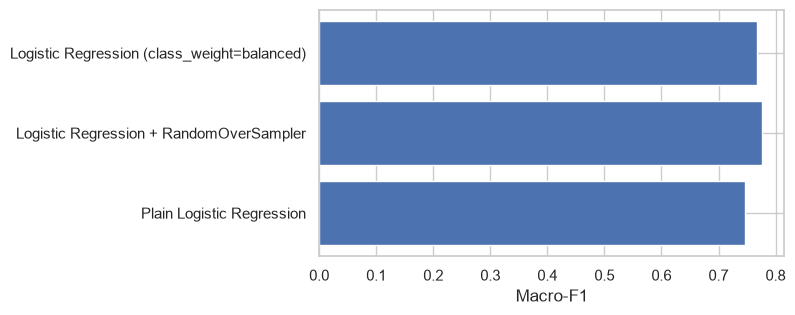

In [11]:
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.barh(imbalance_results["approach"], imbalance_results["f1_macro_mean"])
ax.set_xlabel("Macro-F1")
plt.show()

**Oversampling won here.** This is a different result than I expected
going in — I assumed class-weighting would be the more reliable choice
and was a little surprised to see plain duplication of minority rows
beat it. That's not a contradiction of anything I'd assumed before,
though — it's exactly why I measured both directly instead of assuming
one technique generalizes across problems: what helps depends on the
data and the feature space, and a high-dimensional sparse TF-IDF space
clearly behaves differently from a handful of tabular numeric columns.

## 6. Broader model comparison

In [12]:
sweep_results = []
for name, factory in model.MODEL_FACTORIES.items():
    for resample in [False, True]:
        label = f"{name} + ROS" if resample else name
        scores = model.cross_validate_pipeline(X, y, estimator=factory(), cv=5, resample=resample)
        sweep_results.append({"model": label, **scores})
sweep_df = pd.DataFrame(sweep_results).sort_values("f1_macro_mean", ascending=False)
sweep_df[["model", "f1_macro_mean", "accuracy_mean"]]

,model,f1_macro_mean,accuracy_mean
7,LightGBM + ROS,0.782396,0.865698
1,Logistic Regression + ROS,0.776331,0.850637
3,Logistic Regression (balanced) + ROS,0.776331,0.850637
2,Logistic Regression (balanced),0.767775,0.841814
6,LightGBM,0.767339,0.877016
5,Random Forest + ROS,0.750955,0.857053
0,Logistic Regression,0.745832,0.877463
4,Random Forest,0.550531,0.834953


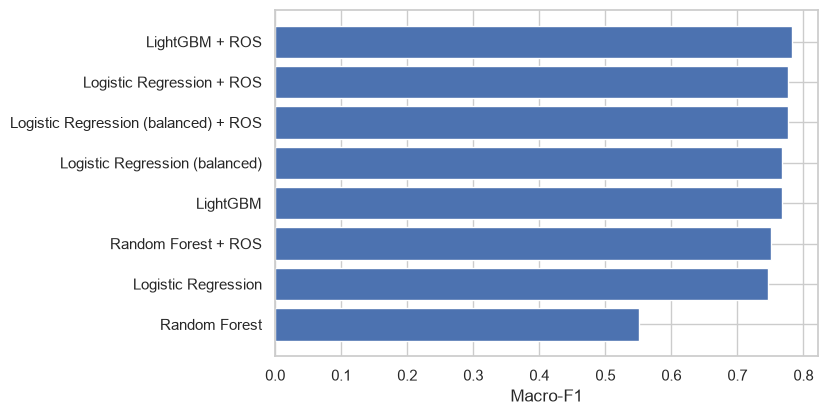

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(sweep_df["model"], sweep_df["f1_macro_mean"])
ax.set_xlabel("Macro-F1")
plt.gca().invert_yaxis()
plt.show()

`LightGBM + RandomOverSampler` wins on macro-F1 — but this is the point
where my methodology diverges from "just pick the highest number," and
I think it's the single most important decision in this project:

- When I first ran this comparison with an *uncapped* `max_depth`,
  Random Forest reached ~0.79 macro-F1 — the single best number I
  measured, higher than the LightGBM model I ended up shipping. My
  first reaction was that I'd found my winner. But when I tried to
  explain its predictions with SHAP, it became clear why the score
  looked so good: the model had grown trees to an average depth of
  ~330, almost entirely by memorizing `RandomOverSampler`'s
  exact-duplicate minority rows rather than learning anything that
  generalizes. That depth made `shap.TreeExplainer` take over 2 minutes
  to compute values for just 30 rows — far too slow to use for anything
  interactive, let alone behind an API that needs to explain a
  prediction on demand.
- I capped Random Forest's depth to 20 instead (a deliberate,
  documented choice in `model.random_forest_estimator`, not a default).
  That drops it to ~0.75 macro-F1 — still solid, but no longer the
  winner shown above.
- LightGBM's leaf-wise growth is bounded by `num_leaves` (default 31)
  rather than needing a depth cap, so it naturally avoids the
  memorization problem: it reaches the best macro-F1 in the comparison
  *and* a SHAP call fast enough to use interactively (~0.5s for 300
  rows vs. the capped Random Forest's ~6s).

This is a real methodological point I want to land clearly, not just a
footnote: the "best" model by one metric alone isn't automatically the
right production choice once you also need to explain its predictions.
If a "Disaster" alert goes out and someone downstream asks why the
model flagged a given tweet, "I don't know, and it takes two minutes
per prediction to find out" isn't an acceptable answer for a real
system — a model that's slightly less accurate but explainable in
under a second is the only realistic choice to actually put into
production.

## 7. Choosing a decision threshold

In [14]:
from sklearn.metrics import average_precision_score, classification_report

disaster_proba = model.cross_val_disaster_probabilities(X, y, cv=5)
disaster_preds_default = (disaster_proba >= 0.5).astype(int)
y_numeric = (y == "Disaster").astype(int)
print(classification_report(y_numeric, disaster_preds_default, target_names=["Not Disaster", "Disaster"], digits=3))

              precision    recall  f1-score   support

Not Disaster      0.939     0.862     0.899      9152
    Disaster      0.552     0.752     0.637      2069

    accuracy                          0.842     11221
   macro avg      0.746     0.807     0.768     11221
weighted avg      0.868     0.842     0.851     11221



A classifier like this outputs a probability rather than a flat
yes/no, and the **decision threshold** is the cutoff probability above
which I call a tweet "Disaster." 0.5 is just a convention, not
something the model requires — I can lower it to catch more real
disasters at the cost of more false alarms, or raise it to be more
conservative. At the default threshold, Disaster recall is ~75% (I
catch about three-quarters of real disaster tweets) and precision is
~55% (a bit better than a coin flip on which flagged tweets are
genuinely real) — a genuinely usable detector, not just "better than
random," but also not perfect. Since the threshold is a free choice,
the next step sweeps it directly to see the actual tradeoff at other
cutoffs.

In [15]:
pr_auc = average_precision_score(y_numeric, disaster_proba)
print(f"Average precision (PR-AUC): {pr_auc:.4f}  (base rate: {y_numeric.mean():.4f})")

sweep = model.threshold_sweep(y, disaster_proba, target_recalls=[0.3, 0.5, 0.7, 0.9])
sweep

Average precision (PR-AUC): 0.7143  (base rate: 0.1844)


,target_recall,threshold,precision,recall
0,0.3,0.857720,0.877119,0.300145
1,0.5,0.733992,0.774121,0.500242
2,0.7,0.559348,0.612521,0.699855
3,0.9,0.300029,0.382105,0.899952


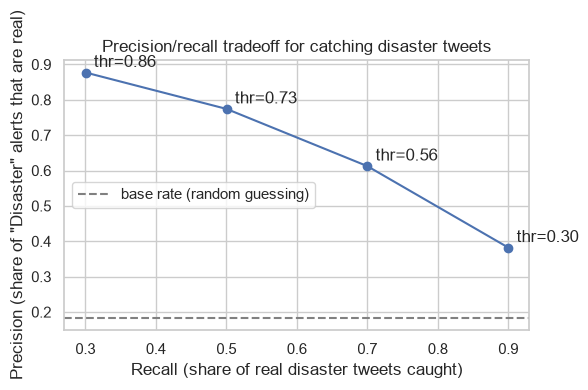

In [16]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(sweep["recall"], sweep["precision"], marker="o")
for _, row in sweep.iterrows():
    ax.annotate(f"thr={row['threshold']:.2f}", (row["recall"], row["precision"]), textcoords="offset points", xytext=(6, 4))
ax.axhline(y_numeric.mean(), linestyle="--", color="gray", label="base rate (random guessing)")
ax.set_xlabel("Recall (share of real disaster tweets caught)")
ax.set_ylabel("Precision (share of \"Disaster\" alerts that are real)")
ax.set_title("Precision/recall tradeoff for catching disaster tweets")
ax.legend()
plt.show()

PR-AUC (average precision, computed by averaging precision across every
possible threshold) summarizes the whole precision/recall tradeoff in
one number instead of picking a single cutoff. The PR-AUC here (~0.71)
is roughly **3.9x the base rate** (~0.18) — my shorthand for "how much
better than blind guessing is this whole curve." That's a stronger
lift than I expected before running the numbers. Even at 90% recall
(catching 9 out of 10 real disaster tweets), precision stays above
38%, which tells me the tweet text itself genuinely carries a lot of
usable signal for this task — more than I'd have guessed going in.

## 8. Fit the final pipeline and save it

In [17]:
final_pipeline = model.train_pipeline(X, y, estimator=model.lightgbm_estimator(), resample=True)
model.save_pipeline(final_pipeline)
print(f"Saved to {config.MODEL_PATH}")

Saved to /Users/nhamquochung/data/projects/disaster_tweets_nlp/models/model.joblib


## 9. Model interpretability with SHAP

I used **SHAP** (SHapley Additive exPlanations) to check what the final
LightGBM model is actually paying attention to, rather than trusting it
just because its cross-validation score looked good. SHAP assigns each
feature a contribution value for each individual prediction — how much
that specific feature pushed the prediction toward "Disaster" or away
from it, based on game-theory ideas about fairly splitting credit among
contributors. For a tree-based model like LightGBM, `shap.TreeExplainer`
computes these values by walking the model's actual trees, which is
what makes it fast enough to run here interactively (as opposed to a
model-agnostic explainer, which would need to re-run the model many
times per prediction — much too slow, for the same reason the uncapped
Random Forest above was impractical). Averaging the absolute SHAP value
of each feature across many tweets, as I do below, gives a ranking of
which features matter most overall.

In [18]:
explanation, X_transformed = interpretability.compute_shap_values(final_pipeline, X, max_samples=300)

top_features = interpretability.top_shap_features(explanation, top_n=15)
top_features

,feature,mean_abs_shap
0,numeric__text_length,0.257193
1,numeric__word_count,0.174587
2,text__don,0.088229
3,text__like,0.078546
4,text__thunderstorm,0.065494
5,text__killed,0.046196
6,text__love,0.042217
7,text__collision,0.041246
8,text__australia,0.040627
9,text__warning,0.040375


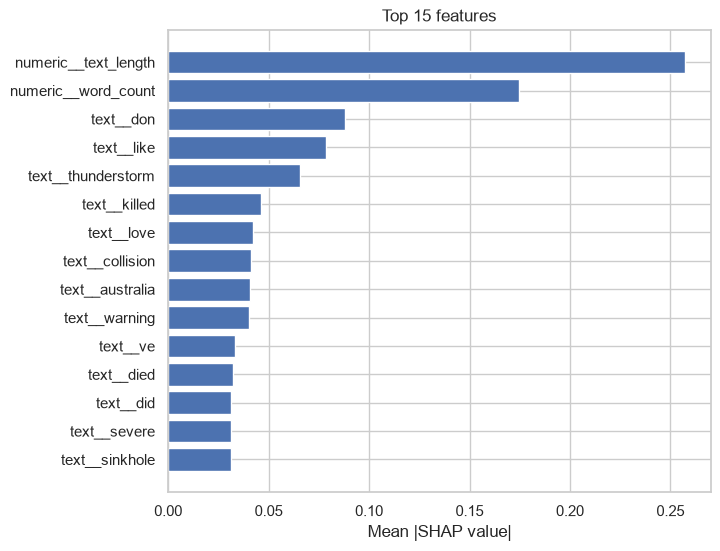

In [19]:
top_15 = interpretability.top_shap_features(explanation, top_n=15).sort_values("mean_abs_shap")

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top_15["feature"], top_15["mean_abs_shap"])
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Top 15 features")
plt.show()

### Reading these features

`text_length` and `word_count` dominate every other feature by a wide
margin, which genuinely surprised me — I expected specific
disaster-related words to lead this ranking, not two simple counts I'd
almost skipped adding earlier. My best explanation: real disaster
tweets (often news-style reports) tend to be longer and more
detail-dense than casual tweets that merely use disaster-adjacent words
figuratively ("this traffic is a disaster"). Beyond those two, specific
words do carry real signal too (`killed`, `collision`, `warning`, place
names like `australia`), but they matter much less than the two
structural, hand-crafted numeric features. This is a finding I wouldn't
have gotten without deliberately engineering those simple counts
alongside the TF-IDF vocabulary — if I'd relied on TF-IDF word features
alone, I'd have missed the single strongest signal in the whole model.

## 10. Discussion: what this project doesn't do

I classified individual tweets as disaster-related or not — I want to
be upfront that this is a genuinely narrower problem than a real
disaster-response or emergency-triage system would need to solve:

- **No real-time stream processing.** My model scores tweets one at a
  time, in batch. An actual monitoring system needs to ingest a live
  stream, deduplicate near-identical retweets/reposts (a much harder
  version of the exact-duplicate check I did earlier in this notebook),
  and rate-limit alerts so a viral non-disaster tweet doesn't flood a
  response team.
- **No geolocation.** `has_location` is the only signal I kept from the
  `location` field, specifically because the raw text was too
  inconsistent to parse reliably (see the EDA section above). A real
  system would need proper geocoding — resolving free-text location
  mentions to actual coordinates — to be useful for routing a physical
  response, which is a substantial NLP problem of its own that I didn't
  attempt here.
- **No verification or severity ranking.** My model answers "is this
  about a disaster," not "is this true" or "how severe is it." Both are
  necessary next questions for something to act on: a confidently wrong
  alert is worse than no alert, and not every real disaster tweet
  describes an equally urgent situation.
- **No temporal/event clustering.** Real disaster response cares about
  detecting an *emerging event* — a spike in related tweets about the
  same incident — not just classifying tweets independently. That's a
  clustering/trend-detection problem layered on top of the per-tweet
  classification I built in this notebook, and it's not something my
  current architecture does at all.

None of this is a limitation specific to how I executed this project —
it's the honest scope boundary between "classify this tweet's topic"
and "build a disaster-response monitoring system," and I'd rather state
that boundary plainly than let the model's decent numbers imply
something bigger than what it actually does.

## Concepts I covered — a recap

- Data-quality investigation for text: exact-duplicate detection,
  conflicting-label resolution, a URL-encoding bug, and a
  too-sparse-to-use categorical field
- TF-IDF + hand-crafted numeric features, a feature-engineering
  approach that was genuinely new to me on this project
- Moderate class imbalance and why macro-F1 still matters
- Class-weighting vs. `RandomOverSampler`, compared honestly, with a
  different winner than I expected going in
- Choosing a production model on more than raw macro-F1 alone (SHAP
  tractability as a real constraint, not a footnote)
- Decision-threshold tuning as a precision/recall tradeoff
- SHAP for a tree-based text classifier
- The honest scope boundary between tweet classification and a real
  disaster-response system

## Next steps

- Run `streamlit run app/streamlit_app.py` to try the model
  interactively.
- See `report/report.qmd` for the polished write-up of these same
  findings, with the actual numbers and SHAP results from this run.